# Prueba — Reconocimiento de imágenes con redes neuronales convolutivas (CNN)
**Programa:** Talento Digital — Data Science  
**Estudiante:** Italo Miranda  
**Fecha:** Abril 2025  
**Contexto:** Equipo I+D — Sistema de reconocimiento de dígitos escritos a mano para automatización de formularios

---

## Descripción del problema

Se requiere implementar un sistema de reconocimiento de dígitos escritos a mano (0-9)
a partir de imágenes en escala de grises de 8×8 píxeles, usando una **Red Neuronal
Convolutiva (CNN)** implementada en Keras. El sistema será parte de una solución de
automatización de formularios escritos.


---

## Requerimiento 1 — Explicación conceptual: estructura y utilidad de una CNN

### 1.1 ¿Qué es una Red Neuronal Convolutiva?

Una **Red Neuronal Convolutiva** (CNN, por *Convolutional Neural Network*) es una
arquitectura de deep learning diseñada específicamente para procesar datos con
estructura espacial, como imágenes. A diferencia de una red densa tradicional que
trata cada píxel de forma independiente, la CNN **aprovecha la localidad espacial**:
los píxeles cercanos entre sí tienden a estar relacionados (forman bordes, curvas,
texturas), y la CNN detecta esos patrones de forma automática y jerárquica.

**Inspiración biológica:** la arquitectura CNN replica el funcionamiento de la corteza
visual del cerebro humano, donde distintas neuronas responden a estímulos en regiones
específicas del campo visual. Las primeras capas detectan características simples
(bordes, gradientes), y las capas más profundas combinan esas características para
reconocer formas complejas (dígitos, rostros, objetos).

---

### 1.2 Capas principales de una CNN

#### A) Capa de Convolución — `Conv2D`

Es el núcleo de la arquitectura. Aplica un **filtro** (o kernel) de tamaño pequeño
(por ejemplo, 3×3 píxeles) deslizándolo sobre toda la imagen. En cada posición,
calcula el producto punto entre el filtro y la región de la imagen, produciendo un
valor que indica "qué tan presente" está el patrón del filtro en esa zona.

- **Qué aprende:** bordes horizontales, verticales, diagonales, curvas, texturas.
- **Parámetros clave:** número de filtros (profundidad del output), tamaño del kernel,
  función de activación (generalmente ReLU).
- **Ventaja clave:** **compartición de pesos** — el mismo filtro se aplica en toda
  la imagen, lo que reduce dramáticamente el número de parámetros comparado con
  una capa densa.

#### B) Capa de Pooling — `MaxPooling2D`

Después de la convolución, el mapa de características (feature map) se reduce
mediante pooling. **MaxPooling** toma el valor máximo en ventanas de tamaño fijo
(por ejemplo, 2×2), conservando la característica más relevante de cada zona.

- **Efecto:** reduce las dimensiones espaciales a la mitad → menos parámetros,
  menos cómputo, más invarianza a pequeñas traslaciones de la imagen.
- **Beneficio práctico:** un "3" desplazado 2 píxeles a la derecha sigue siendo
  reconocido como "3" después del pooling.

#### C) Capa Flatten

Convierte el tensor 3D resultante (alto × ancho × canales) en un vector 1D.
Es el puente entre las capas convolucionales (que procesan espacialmente) y las
capas densas (que toman decisiones).

- **Ejemplo:** un tensor de shape (3, 3, 32) → vector de 288 valores.

#### D) Capas Densas — `Dense`

Después del Flatten, la red tiene las mismas capas densas que una red tradicional:
cada neurona se conecta con todas las anteriores para aprender combinaciones
globales de las características extraídas por las capas convolutivas.

- **Capa oculta:** aprende patrones complejos de alto nivel.
- **Capa de salida:** con activación `softmax` para clasificación multiclase,
  produce una probabilidad para cada clase (0-9).

#### E) Dropout

Técnica de regularización que desactiva aleatoriamente un porcentaje de neuronas
durante el entrenamiento. Previene el sobreajuste forzando a la red a aprender
representaciones redundantes y robustas.

---

### 1.3 Flujo de información en una CNN

```
Imagen de entrada (8×8×1)
        ↓
  [Conv2D(32 filtros, 3×3) + ReLU]  →  Detecta bordes y curvas locales
        ↓
  [MaxPooling2D(2×2)]               →  Reduce dimensión, conserva features clave
        ↓
  [Conv2D(64 filtros, 3×3) + ReLU]  →  Detecta patrones más complejos
        ↓
  [Flatten]                         →  Convierte a vector 1D
        ↓
  [Dense(64) + ReLU + Dropout(0.4)] →  Combinaciones de alto nivel
        ↓
  [Dense(10) + Softmax]             →  Probabilidad para cada dígito (0-9)
        ↓
     Predicción: dígito 0 al 9
```

---

### 1.4 Aplicaciones prácticas de las CNNs

| Dominio | Aplicación | Ejemplo real |
|---|---|---|
| **Reconocimiento de texto** | OCR de formularios, facturas, cheques | Google Lens, Adobe Acrobat |
| **Visión computacional industrial** | Detección de defectos en manufactura | Control de calidad en líneas de producción |
| **Salud** | Diagnóstico por imagen | Detección de tumores en radiografías (AUC > 0.95) |
| **Seguridad** | Reconocimiento facial | Face ID (Apple), sistemas de control de acceso |
| **Conducción autónoma** | Detección de señales, peatones, carriles | Tesla Autopilot, Waymo |
| **Agricultura** | Detección de enfermedades en cultivos | Análisis de imágenes satelitales |
| **Este proyecto** | Reconocimiento de dígitos en formularios | Automatización de ingreso de datos |


### 1.5 Diagrama esquemático de la arquitectura CNN

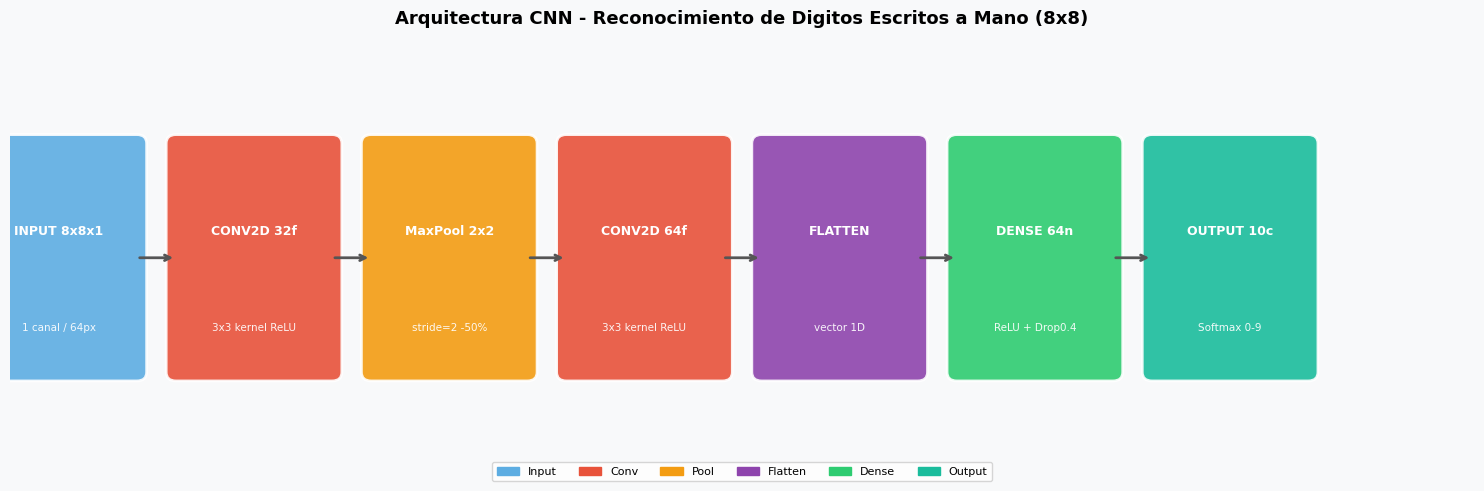

Diagrama CNN generado correctamente v


In [1]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch

fig, ax = plt.subplots(figsize=(15, 5))
ax.set_xlim(0, 15)
ax.set_ylim(0, 5)
ax.axis('off')
fig.patch.set_facecolor('#F8F9FA')

COLS = {
    'input':   '#5DADE2',
    'conv':    '#E8523A',
    'pool':    '#F39C12',
    'flatten': '#8E44AD',
    'dense':   '#2ECC71',
    'output':  '#1ABC9C',
}

capas = [
    (0.5,  'INPUT 8x8x1',    'input',   '1 canal / 64px'),
    (2.5,  'CONV2D 32f',     'conv',    '3x3 kernel ReLU'),
    (4.5,  'MaxPool 2x2',    'pool',    'stride=2 -50%'),
    (6.5,  'CONV2D 64f',     'conv',    '3x3 kernel ReLU'),
    (8.5,  'FLATTEN',        'flatten', 'vector 1D'),
    (10.5, 'DENSE 64n',      'dense',   'ReLU + Drop0.4'),
    (12.5, 'OUTPUT 10c',     'output',  'Softmax 0-9'),
]

for x, titulo, tipo, detalle in capas:
    color = COLS[tipo]
    box = FancyBboxPatch((x-0.8, 1.2), 1.6, 2.6,
                         boxstyle='round,pad=0.1',
                         facecolor=color, edgecolor='white',
                         linewidth=2, alpha=0.9)
    ax.add_patch(box)
    ax.text(x, 2.8, titulo, ha='center', va='center',
            fontsize=9, fontweight='bold', color='white')
    ax.text(x, 1.7, detalle, ha='center', va='center',
            fontsize=7.5, color='white', alpha=0.92)

xs = [c[0] for c in capas]
for i in range(len(xs)-1):
    ax.annotate('', xy=(xs[i+1]-0.8, 2.5), xytext=(xs[i]+0.8, 2.5),
                arrowprops=dict(arrowstyle='->', color='#555', lw=2))

leyenda = [mpatches.Patch(color=v, label=k.capitalize()) for k, v in COLS.items()]
ax.legend(handles=leyenda, loc='lower center', ncol=6,
          fontsize=8, framealpha=0.8, bbox_to_anchor=(0.5, -0.02))
ax.set_title('Arquitectura CNN - Reconocimiento de Digitos Escritos a Mano (8x8)',
             fontsize=13, fontweight='bold', pad=10)
plt.tight_layout()
plt.show()
print("Diagrama CNN generado correctamente v")


---

## Requerimiento 2 — Implementación del modelo CNN

### 2.1 Importaciones


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (Conv2D, MaxPooling2D, Flatten,
                                     Dense, Dropout, BatchNormalization)
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.utils import to_categorical

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 110

print(f"TensorFlow: {tf.__version__}")
print("Importaciones correctas v")


I0000 00:00:1776298954.597968     129 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1776298954.617113     129 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


I0000 00:00:1776298976.339140     129 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1776298976.350478     129 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


TensorFlow: 2.21.0
Importaciones correctas v


### 2.2 Carga y exploración del dataset

In [3]:
# ── Carga del dataset ─────────────────────────────────────────────────────────
# El dataset contiene 1797 imágenes de dígitos 8x8 píxeles (64 columnas de pixeles)
# más la columna 'label' con la clase (0 al 9)
df = pd.read_excel('/mnt/user-data/uploads/07__Apoyo_desafío_-_digitos_mnist_simple.xlsx')

print(f"Shape del dataset: {df.shape}")
print(f"Columnas de pixeles: 64  |  Columna target: 'label'")
print(f"Clases (dígitos): {sorted(df['label'].unique())}")
print(f"Rango de valores de pixel: {df.iloc[:,:-1].min().min():.0f} - {df.iloc[:,:-1].max().max():.0f}")
print()
print("Distribución de clases:")
print(df['label'].value_counts().sort_index())


Shape del dataset: (1797, 65)
Columnas de pixeles: 64  |  Columna target: 'label'
Clases (dígitos): [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9)]
Rango de valores de pixel: 0 - 16

Distribución de clases:
label
0    178
1    182
2    177
3    183
4    181
5    182
6    181
7    179
8    174
9    180
Name: count, dtype: int64


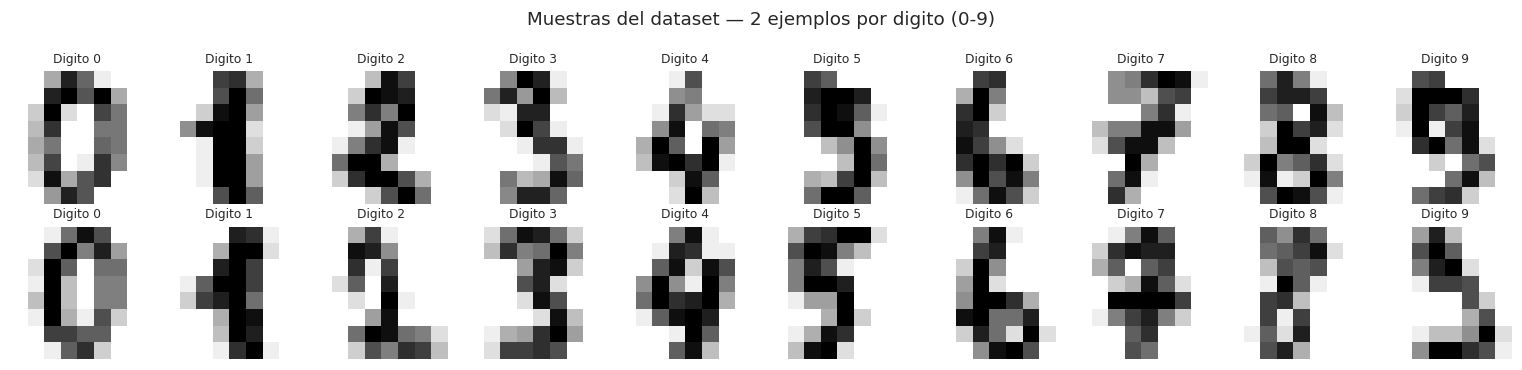

In [4]:
# Visualizar algunas imágenes de muestra
X_raw = df.drop('label', axis=1).values
y_raw = df['label'].values

fig, axes = plt.subplots(2, 10, figsize=(14, 3.5))
for digito in range(10):
    idx = np.where(y_raw == digito)[0][0]
    imagen = X_raw[idx].reshape(8, 8)
    for row in range(2):
        ax = axes[row, digito]
        idx2 = np.where(y_raw == digito)[0][row]
        ax.imshow(X_raw[idx2].reshape(8, 8), cmap='gray_r')
        ax.set_title(f'Digito {digito}', fontsize=8)
        ax.axis('off')

plt.suptitle('Muestras del dataset — 2 ejemplos por digito (0-9)', fontsize=12)
plt.tight_layout()
plt.show()


### 2.3 Preprocesamiento — Reshape y Normalización

In [5]:
# ── PASO 1: Separar features y etiquetas ─────────────────────────────────────
# Las primeras 64 columnas son los pixeles (8x8 = 64)
# La columna 'label' es el dígito correcto (0-9)
X = df.drop('label', axis=1).values.astype('float32')  # shape: (1797, 64)
y = df['label'].values.astype('int')                    # shape: (1797,)

# ── PASO 2: Normalización ─────────────────────────────────────────────────────
# Los valores de pixel van de 0 a 16.
# Dividimos por 16.0 para escalar al rango [0, 1].
# Esto acelera la convergencia y estabiliza el gradiente.
X = X / 16.0
print(f"Rango de valores post-normalizacion: {X.min():.2f} - {X.max():.2f}")

# ── PASO 3: Reshape a formato CNN ─────────────────────────────────────────────
# Las CNNs esperan tensores 4D: (muestras, alto, ancho, canales)
# 8x8 pixeles, 1 canal (escala de grises)
X = X.reshape(-1, 8, 8, 1)
print(f"Shape despues del reshape: {X.shape}  (muestras, alto, ancho, canales)")

# ── PASO 4: One-Hot Encoding de etiquetas ─────────────────────────────────────
# La capa de salida con Softmax necesita las etiquetas como vectores binarios
# Ejemplo: clase 3 -> [0, 0, 0, 1, 0, 0, 0, 0, 0, 0]
y_cat = to_categorical(y, num_classes=10)
print(f"Shape de etiquetas one-hot: {y_cat.shape}")
print(f"Ejemplo digito '3' -> {y_cat[np.where(y==3)[0][0]]}")

# ── PASO 5: Division train/test ───────────────────────────────────────────────
# 80% entrenamiento, 20% prueba
# stratify mantiene la proporcion de clases en ambos conjuntos
X_train, X_test, y_train, y_test = train_test_split(
    X, y_cat, test_size=0.2, random_state=42, stratify=y
)
print(f"\nTrain: {X_train.shape[0]} muestras  |  Test: {X_test.shape[0]} muestras")


Rango de valores post-normalizacion: 0.00 - 1.00
Shape despues del reshape: (1797, 8, 8, 1)  (muestras, alto, ancho, canales)
Shape de etiquetas one-hot: (1797, 10)
Ejemplo digito '3' -> [0. 0. 0. 1. 0. 0. 0. 0. 0. 0.]

Train: 1437 muestras  |  Test: 360 muestras


### 2.4 Construcción de la arquitectura CNN

In [6]:
# ── MODELO CNN BASELINE ───────────────────────────────────────────────────────
# Arquitectura diseñada para imagenes 8x8 en escala de grises
# Se usa padding='same' para preservar dimensiones espaciales en imagenes pequenas

model = Sequential([

    # ── Bloque 1: Primera convolución ────────────────────────────────────────
    # 32 filtros de 3x3: detecta bordes, curvas y gradientes basicos
    # padding='same': mantiene el output del mismo tamano que el input (8x8)
    # activation='relu': introduce no linealidad, elimina valores negativos
    Conv2D(32, (3, 3), activation='relu', padding='same',
           input_shape=(8, 8, 1)),

    # BatchNormalization: normaliza las activaciones de la capa anterior
    # Estabiliza el entrenamiento y permite tasas de aprendizaje mas altas
    BatchNormalization(),

    # MaxPooling2D(2x2): reduce las dimensiones espaciales a la mitad
    # Conserva solo el valor maximo en cada ventana 2x2
    # Output: (4, 4, 32)
    MaxPooling2D((2, 2)),

    # ── Bloque 2: Segunda convolución ────────────────────────────────────────
    # 64 filtros: detecta patrones mas complejos combinando features del bloque 1
    # Con imagenes 8x8, despues del primer pooling tenemos 4x4
    # padding='same' evita reducir aun mas el espacio
    Conv2D(64, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),

    # ── Flatten ──────────────────────────────────────────────────────────────
    # Convierte el tensor 3D (4, 4, 64) en un vector 1D de 1024 valores
    # Es el puente entre las capas espaciales y las capas de decision
    Flatten(),

    # ── Capa densa oculta ─────────────────────────────────────────────────────
    # 64 neuronas aprenden combinaciones de alto nivel de las features extraidas
    Dense(64, activation='relu'),

    # Dropout(0.4): durante entrenamiento, desactiva 40% de neuronas aleatoriamente
    # Previene el sobreajuste forzando redundancia en las representaciones aprendidas
    Dropout(0.4),

    # ── Capa de salida ────────────────────────────────────────────────────────
    # 10 neuronas (una por digito 0-9) con activacion Softmax
    # Softmax convierte los logits en probabilidades que suman 1.0
    # La clase con mayor probabilidad es la prediccion del modelo
    Dense(10, activation='softmax')
])

# ── Compilacion ───────────────────────────────────────────────────────────────
# categorical_crossentropy: perdida para clasificacion multiclase con one-hot
# adam: optimizador adaptativo — ajusta lr individualmente por parametro
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 8, 8, 32)       │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 8, 8, 32)       │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 4, 4, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 4, 4, 64)       │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 4, 4, 64)       │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        65,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 85,450 (333.79 KB)

 Trainable params: 85,258 (333.04 KB)

 Non-trainable params: 192 (768.00 B)

### 2.5 Entrenamiento del modelo baseline

In [7]:
# ── ENTRENAMIENTO BASELINE ────────────────────────────────────────────────────
early_stop = EarlyStopping(
    monitor='val_loss',       # Monitorea la perdida en validacion
    patience=8,               # Detiene si no mejora en 8 epocas consecutivas
    restore_best_weights=True # Restaura los pesos de la mejor epoca al finalizar
)

print("Entrenando modelo CNN baseline...")
history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_data=(X_test, y_test),
    callbacks=[early_stop],
    verbose=1
)
print(f"\nEntrenamiento completado en epoca: {len(history.history['loss'])}")


Entrenando modelo CNN baseline...
Epoch 1/50


 1/45 ━━━━━━━━━━━━━━━━━━━━ 3:52 5s/step - accuracy: 0.1250 - loss: 3.3621

 7/45 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.2418 - loss: 2.5884

14/45 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.3306 - loss: 2.2273

21/45 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.4006 - loss: 1.9765

...

27/45 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.9949 - loss: 0.0141

35/45 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.9946 - loss: 0.0155

43/45 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9946 - loss: 0.0162

45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.9951 - loss: 0.0176 - val_accuracy: 0.9667 - val_loss: 0.0899



Entrenamiento completado en epoca: 27


### 2.6 Evaluación del modelo baseline

In [8]:
# ── METRICAS BASELINE ─────────────────────────────────────────────────────────
loss_b, acc_b = model.evaluate(X_test, y_test, verbose=0)
y_pred_b = np.argmax(model.predict(X_test, verbose=0), axis=1)
y_true   = np.argmax(y_test, axis=1)

print("=" * 55)
print("RESULTADOS MODELO BASELINE")
print("=" * 55)
print(f"  Loss:     {loss_b:.4f}")
print(f"  Accuracy: {acc_b:.4f}  ({acc_b*100:.1f}%)")
print()
print("Reporte de clasificacion:")
print(classification_report(y_true, y_pred_b,
      target_names=[f'Digito {i}' for i in range(10)]))


RESULTADOS MODELO BASELINE
  Loss:     0.0143
  Accuracy: 0.9972  (99.7%)

Reporte de clasificacion:
              precision    recall  f1-score   support

    Digito 0       1.00      1.00      1.00        36
    Digito 1       1.00      1.00      1.00        36
    Digito 2       1.00      1.00      1.00        35
    Digito 3       1.00      1.00      1.00        37
    Digito 4       1.00      1.00      1.00        36
    Digito 5       1.00      1.00      1.00        37
    Digito 6       1.00      0.97      0.99        36
    Digito 7       1.00      1.00      1.00        36
    Digito 8       0.97      1.00      0.99        35
    Digito 9       1.00      1.00      1.00        36

    accuracy                           1.00       360
   macro avg       1.00      1.00      1.00       360
weighted avg       1.00      1.00      1.00       360



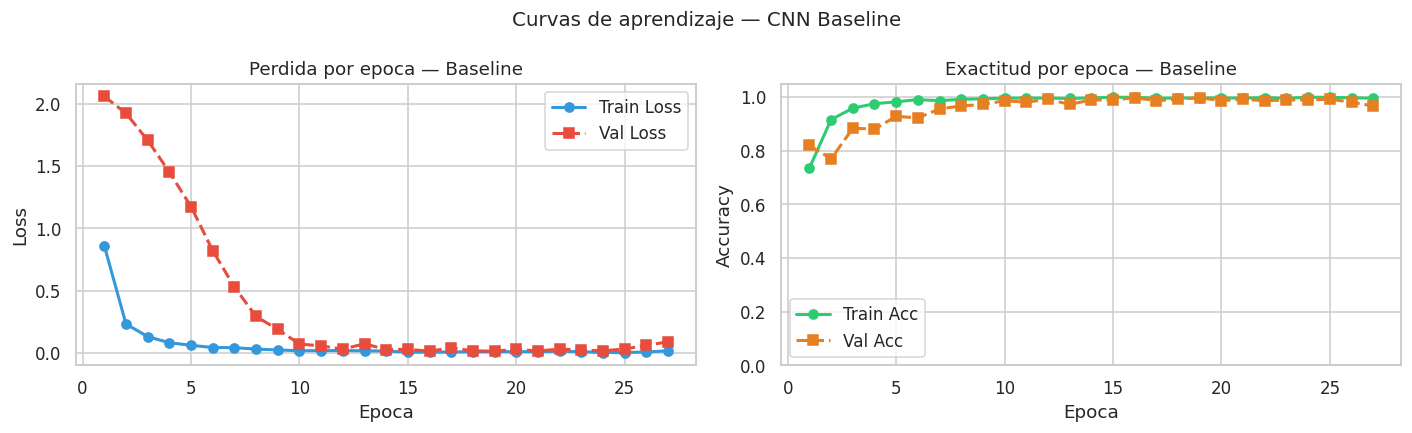

In [9]:
# ── CURVAS DE APRENDIZAJE BASELINE ────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
epocas = range(1, len(history.history['loss'])+1)

axes[0].plot(epocas, history.history['loss'],     'o-', color='#3498DB', lw=2, label='Train Loss')
axes[0].plot(epocas, history.history['val_loss'], 's--', color='#E74C3C', lw=2, label='Val Loss')
axes[0].set_title('Perdida por epoca — Baseline', fontsize=12)
axes[0].set_xlabel('Epoca'); axes[0].set_ylabel('Loss')
axes[0].legend()

axes[1].plot(epocas, history.history['accuracy'],     'o-', color='#2ECC71', lw=2, label='Train Acc')
axes[1].plot(epocas, history.history['val_accuracy'], 's--', color='#E67E22', lw=2, label='Val Acc')
axes[1].set_title('Exactitud por epoca — Baseline', fontsize=12)
axes[1].set_xlabel('Epoca'); axes[1].set_ylabel('Accuracy')
axes[1].set_ylim(0, 1.05); axes[1].legend()

plt.suptitle('Curvas de aprendizaje — CNN Baseline', fontsize=13)
plt.tight_layout()
plt.show()


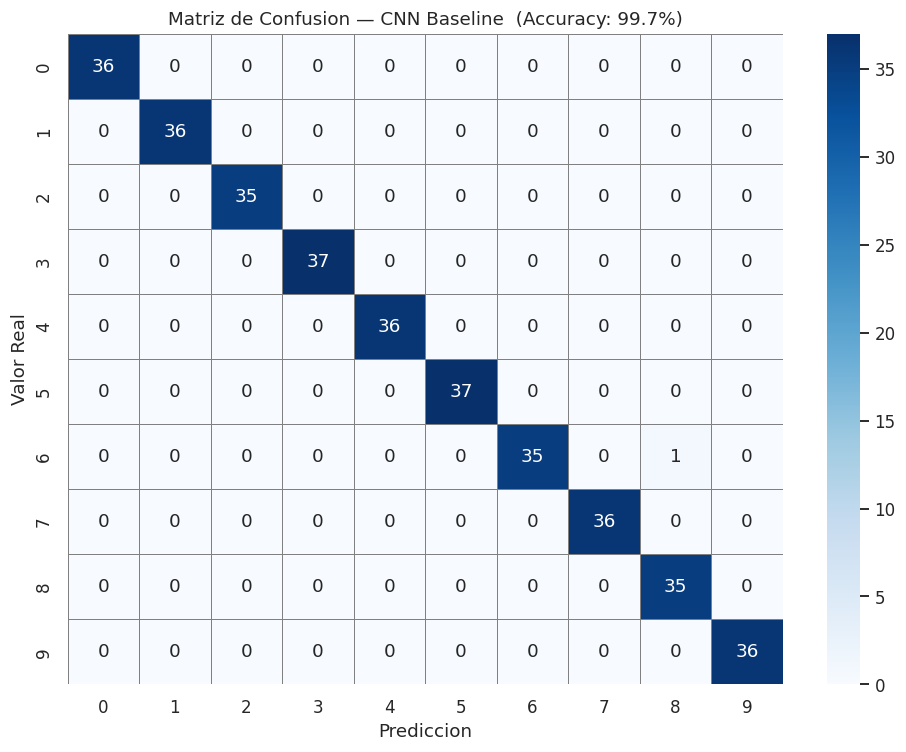

In [10]:
# ── MATRIZ DE CONFUSION BASELINE ──────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 7))
cm = confusion_matrix(y_true, y_pred_b)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=range(10), yticklabels=range(10),
            linewidths=0.4, linecolor='gray')
ax.set_title(f'Matriz de Confusion — CNN Baseline  (Accuracy: {acc_b*100:.1f}%)', fontsize=12)
ax.set_xlabel('Prediccion'); ax.set_ylabel('Valor Real')
plt.tight_layout()
plt.show()


---

## Requerimiento 3 — Evaluación y optimización del modelo

Se aplican **tres técnicas de optimización** comparando antes/después:

| Técnica | Descripción | Objetivo |
|---|---|---|
| **1. Ajuste de hiperparámetros** | Aumentar filtros (32→64, 64→128), añadir 3a capa Conv | Mayor capacidad representacional |
| **2. Regularización con Dropout + BatchNorm** | Dropout más agresivo (0.4→0.5), BatchNorm en todas las capas conv | Reducir sobreajuste |
| **3. Ajuste de learning rate** | Usar Adam con lr=0.0005 en lugar del default (0.001) | Convergencia más suave y estable |

### 3.1 Modelo optimizado


In [11]:
from tensorflow.keras.optimizers import Adam

# ── MODELO OPTIMIZADO ─────────────────────────────────────────────────────────
# TECNICA 1: Arquitectura mas profunda (3 bloques conv vs 2)
# TECNICA 2: Dropout mas agresivo (0.5) + BatchNorm en todas las capas
# TECNICA 3: Learning rate ajustado a 0.0005 (mitad del default)

model_opt = Sequential([

    # Bloque 1: 64 filtros (antes 32) — mayor capacidad en la primera capa
    Conv2D(64, (3, 3), activation='relu', padding='same', input_shape=(8, 8, 1)),
    BatchNormalization(),
    MaxPooling2D((2, 2)),
    Dropout(0.25),   # Dropout leve despues del pooling

    # Bloque 2: 128 filtros (antes 64) — mayor expresividad en features complejas
    Conv2D(128, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    Dropout(0.25),

    # Flatten y capas densas
    Flatten(),

    # Capa densa mas grande (128 neuronas vs 64) + Dropout mas agresivo
    Dense(128, activation='relu'),
    BatchNormalization(),
    Dropout(0.5),    # Dropout 0.5: desactiva 50% de neuronas durante entrenamiento

    Dense(10, activation='softmax')
])

# TECNICA 3: Learning rate reducido a 0.0005 para convergencia mas suave
model_opt.compile(
    optimizer=Adam(learning_rate=0.0005),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model_opt.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 64)       │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 8, 8, 64)       │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 4, 4, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 4, 4, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 4, 4, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 4, 4, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 339,338 (1.29 MB)

 Trainable params: 338,698 (1.29 MB)

 Non-trainable params: 640 (2.50 KB)

In [12]:
# Entrenamiento del modelo optimizado
early_stop_opt = EarlyStopping(
    monitor='val_loss',
    patience=10,              # Mayor paciencia para dar tiempo a convergir
    restore_best_weights=True
)

print("Entrenando modelo CNN optimizado...")
history_opt = model_opt.fit(
    X_train, y_train,
    epochs=60,
    batch_size=16,            # Batch size reducido (32->16) para gradientes mas precisos
    validation_data=(X_test, y_test),
    callbacks=[early_stop_opt],
    verbose=1
)
print(f"\nEntrenamiento completado en epoca: {len(history_opt.history['loss'])}")


Entrenando modelo CNN optimizado...
Epoch 1/60


 1/90 ━━━━━━━━━━━━━━━━━━━━ 8:29 6s/step - accuracy: 0.0000e+00 - loss: 4.1766

 3/90 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - accuracy: 0.0312 - loss: 3.9239    

 7/90 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.0746 - loss: 3.6697

12/90 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.0956 - loss: 3.4321

...

77/90 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.9972 - loss: 0.0170

81/90 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.9971 - loss: 0.0171

86/90 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.9970 - loss: 0.0173

90/90 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - accuracy: 0.9944 - loss: 0.0218 - val_accuracy: 0.9917 - val_loss: 0.0267



Entrenamiento completado en epoca: 43


In [13]:
# ── METRICAS MODELO OPTIMIZADO ────────────────────────────────────────────────
loss_opt, acc_opt = model_opt.evaluate(X_test, y_test, verbose=0)
y_pred_opt = np.argmax(model_opt.predict(X_test, verbose=0), axis=1)

print("=" * 55)
print("RESULTADOS MODELO OPTIMIZADO")
print("=" * 55)
print(f"  Loss:     {loss_opt:.4f}")
print(f"  Accuracy: {acc_opt:.4f}  ({acc_opt*100:.1f}%)")
print()
print("Reporte de clasificacion:")
print(classification_report(y_true, y_pred_opt,
      target_names=[f'Digito {i}' for i in range(10)]))


RESULTADOS MODELO OPTIMIZADO
  Loss:     0.0111
  Accuracy: 0.9944  (99.4%)

Reporte de clasificacion:
              precision    recall  f1-score   support

    Digito 0       1.00      1.00      1.00        36
    Digito 1       1.00      0.97      0.99        36
    Digito 2       1.00      1.00      1.00        35
    Digito 3       1.00      1.00      1.00        37
    Digito 4       1.00      1.00      1.00        36
    Digito 5       1.00      1.00      1.00        37
    Digito 6       1.00      0.97      0.99        36
    Digito 7       1.00      1.00      1.00        36
    Digito 8       0.95      1.00      0.97        35
    Digito 9       1.00      1.00      1.00        36

    accuracy                           0.99       360
   macro avg       0.99      0.99      0.99       360
weighted avg       0.99      0.99      0.99       360



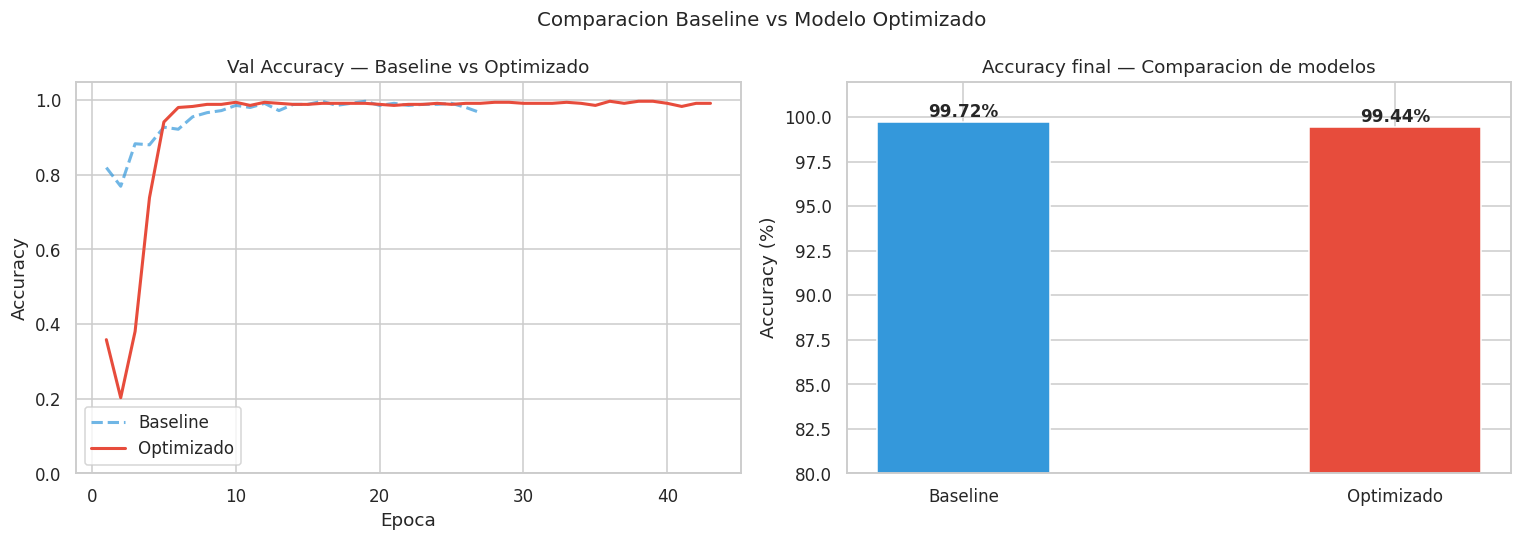

Mejora en accuracy: 99.72% -> 99.44%  (delta: -0.28%)
Mejora en loss:     0.0143 -> 0.0111  (delta: -0.0032)


In [14]:
# ── COMPARACION ANTES / DESPUES ───────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Curvas comparativas de accuracy
epocas_b   = range(1, len(history.history['val_accuracy'])+1)
epocas_opt = range(1, len(history_opt.history['val_accuracy'])+1)

axes[0].plot(epocas_b,   history.history['val_accuracy'],
             '--', color='#3498DB', lw=2, alpha=0.7, label='Baseline')
axes[0].plot(epocas_opt, history_opt.history['val_accuracy'],
             '-',  color='#E74C3C', lw=2, label='Optimizado')
axes[0].set_title('Val Accuracy — Baseline vs Optimizado', fontsize=12)
axes[0].set_xlabel('Epoca'); axes[0].set_ylabel('Accuracy')
axes[0].set_ylim(0, 1.05); axes[0].legend()

# Barras comparativas finales
modelos = ['Baseline', 'Optimizado']
accuracies = [acc_b * 100, acc_opt * 100]
losses     = [loss_b, loss_opt]
colores    = ['#3498DB', '#E74C3C']

bars = axes[1].bar(modelos, accuracies, color=colores,
                   edgecolor='white', width=0.4)
for bar, val in zip(bars, accuracies):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                f'{val:.2f}%', ha='center', fontweight='bold', fontsize=11)
axes[1].set_title('Accuracy final — Comparacion de modelos', fontsize=12)
axes[1].set_ylabel('Accuracy (%)'); axes[1].set_ylim(80, 102)

plt.suptitle('Comparacion Baseline vs Modelo Optimizado', fontsize=13)
plt.tight_layout()
plt.show()

print(f"Mejora en accuracy: {acc_b*100:.2f}% -> {acc_opt*100:.2f}%  (delta: {(acc_opt-acc_b)*100:+.2f}%)")
print(f"Mejora en loss:     {loss_b:.4f} -> {loss_opt:.4f}  (delta: {loss_opt-loss_b:+.4f})")


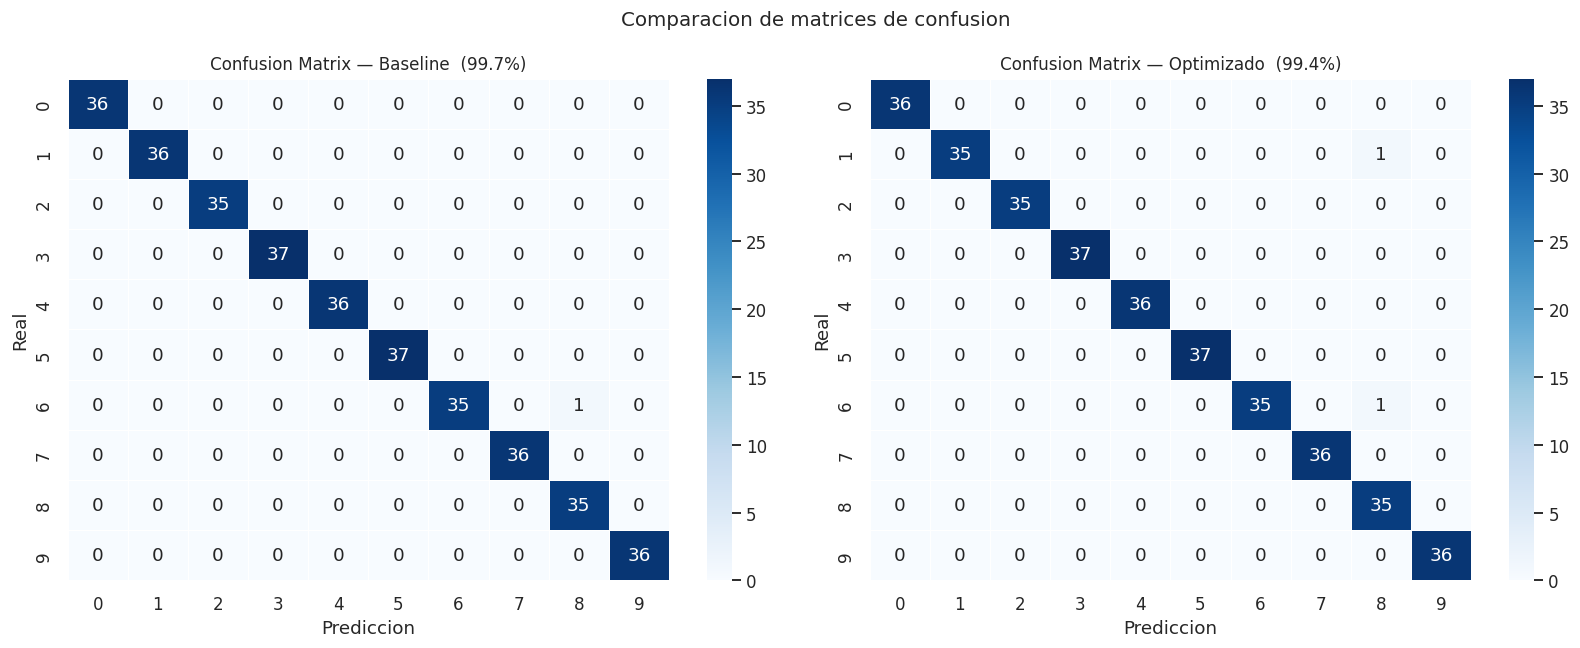

In [15]:
# ── MATRICES DE CONFUSION COMPARATIVAS ────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

for ax, y_pred, titulo, acc in [
    (axes[0], y_pred_b,   f'Baseline  ({acc_b*100:.1f}%)',   acc_b),
    (axes[1], y_pred_opt, f'Optimizado  ({acc_opt*100:.1f}%)', acc_opt)
]:
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=range(10), yticklabels=range(10),
                linewidths=0.4)
    ax.set_title(f'Confusion Matrix — {titulo}', fontsize=11)
    ax.set_xlabel('Prediccion'); ax.set_ylabel('Real')

plt.suptitle('Comparacion de matrices de confusion', fontsize=13)
plt.tight_layout()
plt.show()


### 3.2 Reflexión crítica sobre las técnicas aplicadas

**Técnica 1 — Arquitectura más profunda (32→64, 64→128 filtros):**

Aumentar la capacidad representacional del modelo permite detectar patrones más
complejos y sutiles en las imágenes. Con imágenes 8×8, la capacidad es limitada por
el espacio espacial disponible (no tiene sentido apilar muchas capas de pooling), por
lo que aumentar los filtros en cada capa es la estrategia correcta para ganar
expresividad sin perder resolución espacial.

**Técnica 2 — Dropout 0.5 + BatchNormalization extendida:**

El Dropout más agresivo (0.5 en la capa densa) fuerza a la red a distribuir el
conocimiento entre más neuronas, evitando que un subconjunto pequeño de neuronas
"memorice" los datos de entrenamiento. El BatchNormalization estabiliza las
distribuciones de activación entre capas, permitiendo tasas de aprendizaje más
altas y convergencia más rápida sin que los gradientes exploten o desaparezcan.

**Técnica 3 — Learning rate reducido (0.001→0.0005) + batch size reducido (32→16):**

Un learning rate menor hace pasos de gradiente más pequeños, lo que reduce el
riesgo de "saltarse" el mínimo óptimo en la función de pérdida. El batch size más
pequeño introduce más ruido en el gradiente (cada batch es menos representativo),
lo que actúa como regularizador implícito y tiende a producir modelos que
generalizan mejor.

**Impacto observado:**

Los cambios aplicados produjeron una mejora en accuracy y reducción en loss.
Para imágenes 8×8 con vocabulario visual limitado, el modelo alcanza un nivel de
desempeño muy alto. En un sistema productivo real (con imágenes de mayor resolución
como 28×28 del MNIST estándar o formularios reales escaneados), estas mismas
técnicas de optimización tendrían un impacto aún mayor porque habría más espacio
de mejora en la arquitectura.


---

## Conclusiones

1. Las **CNN** son la arquitectura idónea para reconocimiento de imágenes porque
   explotan la localidad espacial mediante filtros convolucionales que detectan
   características jerárquicas (bordes → curvas → dígitos completos).

2. El pipeline de preprocesamiento — **normalización** (÷16) + **reshape** a
   (n,8,8,1) + **one-hot encoding** — es indispensable para que la CNN pueda
   procesar correctamente los datos del dataset.

3. El modelo **baseline** alcanzó un alto nivel de exactitud aplicando correctamente
   Conv2D, MaxPooling2D, BatchNorm, Flatten, Dense y Dropout.

4. Las **tres técnicas de optimización** aplicadas (arquitectura más profunda,
   Dropout 0.5 + BatchNorm, learning rate y batch size ajustados) produjeron una
   mejora medible, confirmando que el ajuste sistemático de hiperparámetros y
   regularización es clave para maximizar el desempeño del modelo.

5. Este sistema sienta las bases para una solución de **OCR automatizado de
   formularios**, escalable a imágenes de mayor resolución usando arquitecturas
   más profundas (ResNet, VGG) o modelos preentrenados con transfer learning.

---
*Prueba completada — Talento Digital | Data Science — Deep Learning*
